<a href="https://colab.research.google.com/github/sahiser19/ST-554-/blob/main/HW_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part I - More Practice Querying a Database (16 pts)
1. Connect to the database and then look at all of the tables in the database (use read_sql() from
pandas to have this returned as a data frame). (2 pts)
2. Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the
playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns. The summing can
be done in pandas or in the SQL call. (6 pts)
3. For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the
playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO. The summing can be done in pandas
or in the SQL call. (4 pts)
4. Using pandas join the previous two tables together by pitcher. (If you want, try to do all of this via
SQL! Not required though, feel free to use pd.merge() if you’d like) (4 pts)

In [13]:
#Part 1
import pandas as pd
import sqlite3
#make the connection to the .db file.
con = sqlite3.connect("lahman_1871-2022.sqlite")


In [19]:
#Part 1.1
tables_df = pd.read_sql_query("""
SELECT name AS table_name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""", con)

tables_df

,table_name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


In [20]:
#Part 1.2
hof_pitching_totals = pd.read_sql_query("""
SELECT
    p.playerID,
    SUM(p.GS)    AS GS,
    SUM(p.G)     AS G,
    SUM(p.W)     AS W,
    SUM(p.L)     AS L,
    SUM(p.IPOuts) AS IPOuts,
    SUM(p.CG)    AS CG,
    SUM(p.SHO)   AS SHO,
    SUM(p.SV)    AS SV
FROM Pitching AS p
JOIN (
    SELECT DISTINCT playerID
    FROM HallOfFame
    WHERE inducted = 'Y'
) AS h
ON p.playerID = h.playerID
GROUP BY p.playerID
ORDER BY p.playerID;
""", con)

hof_pitching_totals.head()

,playerID,GS,G,W,L,IPOuts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0


In [21]:
#Part 1.3
hof_pitcher_batting_totals = pd.read_sql_query("""
SELECT
    b.playerID,
    SUM(b.AB)  AS AB,
    SUM(b.R)   AS R,
    SUM(b.H)   AS H,
    SUM(b.HR)  AS HR,
    SUM(b.RBI) AS RBI,
    SUM(b.BB)  AS BB,
    SUM(b.SO)  AS SO
FROM Batting AS b
JOIN (
    SELECT DISTINCT p.playerID
    FROM Pitching AS p
    JOIN HallOfFame AS h
      ON p.playerID = h.playerID
    WHERE h.inducted = 'Y'
) AS hp
ON b.playerID = hp.playerID
GROUP BY b.playerID
ORDER BY b.playerID;
""", con)

hof_pitcher_batting_totals.head()

,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193


In [22]:
#Part 1.4
hof_pitchers_combined = pd.merge(
    hof_pitching_totals,
    hof_pitcher_batting_totals,
    on="playerID",
    how="left"   # keep all pitchers; batting may be missing
)

hof_pitchers_combined.head()

,playerID,GS,G,W,L,IPOuts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193


Part II - Messing with Classes

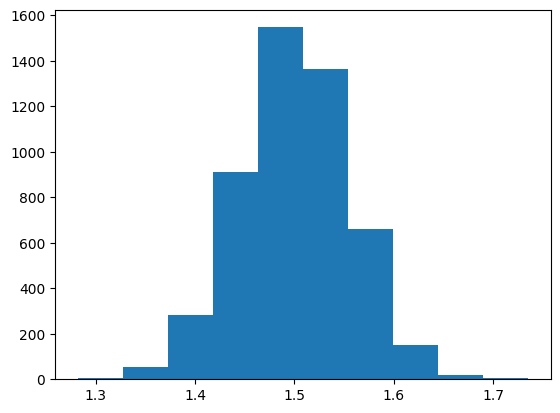

In [38]:
#Part 2.0
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)
#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000): ##so repeat 5000 times and create a bit of new "noise" each time via the rsn() code
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]
#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [39]:
#Part 2.0
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

In [50]:
#Part 2.1
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression


class SLR_slope_simulator:

    def __init__(self, beta_0, beta_1, x, sigma, seed):
        """
        Initialize the simulator.
        """
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.x = np.array(x)
        self.sigma = sigma

        self.n = len(self.x)
        self.rng = default_rng(seed)

        self.slopes = []


    def generate_data(self):
        """
        Generates one dataset (x, y)
        """
        noise = self.rng.normal(0, self.sigma, self.n)
        y = self.beta_0 + self.beta_1 * self.x + noise
        return self.x, y


    def fit_slope(self, x, y):
        """
        Fits SLR and returns estimated slope
        """
        model = LinearRegression()
        model.fit(x.reshape(-1, 1), y)
        return model.coef_[0]


    def run_simulations(self, num_simulations):
        """
        Runs repeated simulations and stores slope estimates.
        Does NOT return anything.
        Replaces self.slopes with numpy array of slope estimates.
        """

        slope_estimates = np.zeros(int(num_simulations))

        for i in range(int(num_simulations)):
            x, y = self.generate_data()
            slope_estimates[i] = self.fit_slope(x, y)

        self.slopes = slope_estimates


    def plot_sampling_distribution(self, bins=40):
        """
        Plot histogram of slopes if simulations have been run.
        """
        if len(self.slopes) == 0:
            print("No slopes available. Call run_simulations() first.")
            return

        plt.hist(self.slopes, bins=bins)
        plt.xlabel("Estimated slope")
        plt.ylabel("Count")
        plt.title("Sampling distribution of the slope estimator")
        plt.show()


    def find_prob(self, value, sided="above"):
        """
        Approximate probabilities from the simulated slope distribution.
        """
        if len(self.slopes) == 0:
            print("No slopes available. Call run_simulations() first.")
            return None

        value = float(value)
        sided = sided.lower()

        if sided == "above":
            return np.mean(self.slopes > value)
        elif sided == "below":
            return np.mean(self.slopes < value)
        elif sided == "two-sided":
            return np.mean(np.abs(self.slopes) > abs(value))
        else:
            raise ValueError("sided must be 'above', 'below', or 'two-sided'")

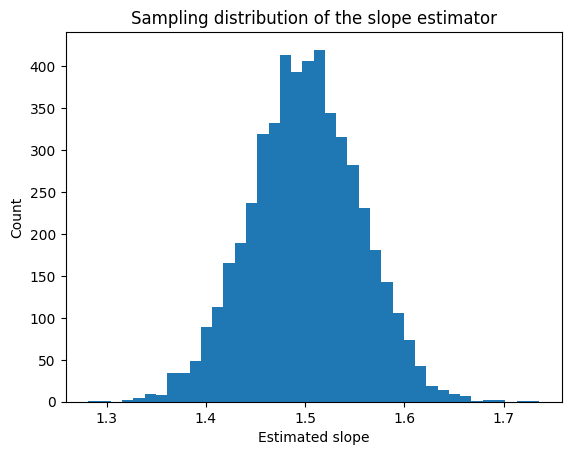

(np.float64(0.0038), np.float64(0.0352), np.float64(0.0038))

In [51]:
#Part 2.2
x = np.array(list(np.linspace(0, 10, 11)) * 3)

sim = SLR_slope_simulator(beta_0=7, beta_1=1.5, x=x, sigma=1, seed=32)
sim.run_simulations(5000)

sim.plot_sampling_distribution()

p_above_165 = sim.find_prob(1.65, sided="above")
p_below_14  = sim.find_prob(1.4, sided="below")
p_two_sided = sim.find_prob(1.65, sided="two-sided")

p_above_165, p_below_14, p_two_sided

Error message: 'SLR_slope_simulator' object has no attribute 'run_simulation'


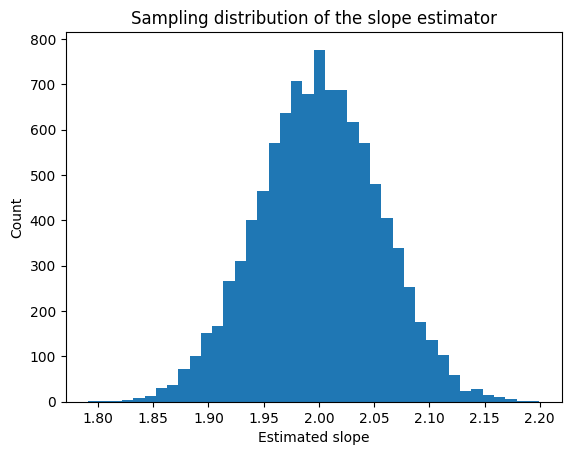

Two-sided probability P(|slope| > 2.1): 0.0352
Simulated slopes array:
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


In [52]:
#Part 2.3
import numpy as np

# Create x as specified
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)

# Create an instance with the requested parameters
sim = SLR_slope_simulator(beta_0=12, beta_1=2, x=x, sigma=1, seed=10)

# Call run_simulation() to get the error message
try:
    sim.run_simulation()
except AttributeError as e:
    print("Error message:", e)

# Run 10000 simulations
sim.run_simulations(10000)

# Plot the sampling distribution
sim.plot_sampling_distribution()

# Approximate the two-sided probability of being larger than 2.1
# (two-sided here means P(|slope| > |2.1|) per the assignment)
p_two_sided = sim.find_prob(2.1, sided="two-sided")
print("Two-sided probability P(|slope| > 2.1):", p_two_sided)

# Print out the simulated slopes using the attribute
print("Simulated slopes array:")
print(sim.slopes)